In [ ]:
# EdgeSense AI - Module 1: Human Activity Recognition
# Intern: Jeni | Project: Embedded AI on Edge

!pip install tensorflow numpy pandas matplotlib scikit-learn seaborn -q
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All imports successful!")

✅ TensorFlow version: 2.20.0
✅ All imports successful!


In [ ]:
# Simulating Accelerometer + Gyroscope sensor data
# This mimics real MPU6050 sensor readings on edge devices

np.random.seed(42)
n_samples = 3000

def generate_activity_data(activity, n):
    if activity == 'Walking':
        ax = np.random.normal(0.5, 0.3, n)
        ay = np.random.normal(0.8, 0.2, n)
        az = np.random.normal(0.3, 0.15, n)
        gx = np.random.normal(1.2, 0.4, n)
        gy = np.random.normal(0.9, 0.3, n)
        gz = np.random.normal(0.4, 0.2, n)
    elif activity == 'Running':
        ax = np.random.normal(1.8, 0.5, n)
        ay = np.random.normal(2.1, 0.4, n)
        az = np.random.normal(1.2, 0.3, n)
        gx = np.random.normal(3.5, 0.6, n)
        gy = np.random.normal(2.8, 0.5, n)
        gz = np.random.normal(1.9, 0.4, n)
    elif activity == 'Sitting':
        ax = np.random.normal(0.05, 0.02, n)
        ay = np.random.normal(0.03, 0.02, n)
        az = np.random.normal(0.98, 0.01, n)
        gx = np.random.normal(0.1, 0.05, n)
        gy = np.random.normal(0.08, 0.04, n)
        gz = np.random.normal(0.05, 0.03, n)
    elif activity == 'Standing':
        ax = np.random.normal(0.1, 0.05, n)
        ay = np.random.normal(0.08, 0.04, n)
        az = np.random.normal(0.95, 0.03, n)
        gx = np.random.normal(0.2, 0.08, n)
        gy = np.random.normal(0.15, 0.06, n)
        gz = np.random.normal(0.1, 0.05, n)
    elif activity == 'Falling':
        ax = np.random.normal(3.5, 0.8, n)
        ay = np.random.normal(3.2, 0.7, n)
        az = np.random.normal(2.8, 0.6, n)
        gx = np.random.normal(5.0, 1.0, n)
        gy = np.random.normal(4.5, 0.9, n)
        gz = np.random.normal(3.8, 0.8, n)

    return pd.DataFrame({
        'accel_x': ax, 'accel_y': ay, 'accel_z': az,
        'gyro_x': gx, 'gyro_y': gy, 'gyro_z': gz,
        'activity': activity
    })

# Generate data for all activities
activities = ['Walking', 'Running', 'Sitting', 'Standing', 'Falling']
dfs = [generate_activity_data(act, n_samples) for act in activities]
df = pd.concat(dfs, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Dataset created: {df.shape[0]} samples, {df.shape[1]} features")
print(f"\n📊 Activity Distribution:")
print(df['activity'].value_counts())

✅ Dataset created: 15000 samples, 7 features

📊 Activity Distribution:
activity
Standing    3000
Sitting     3000
Falling     3000
Walking     3000
Running     3000
Name: count, dtype: int64


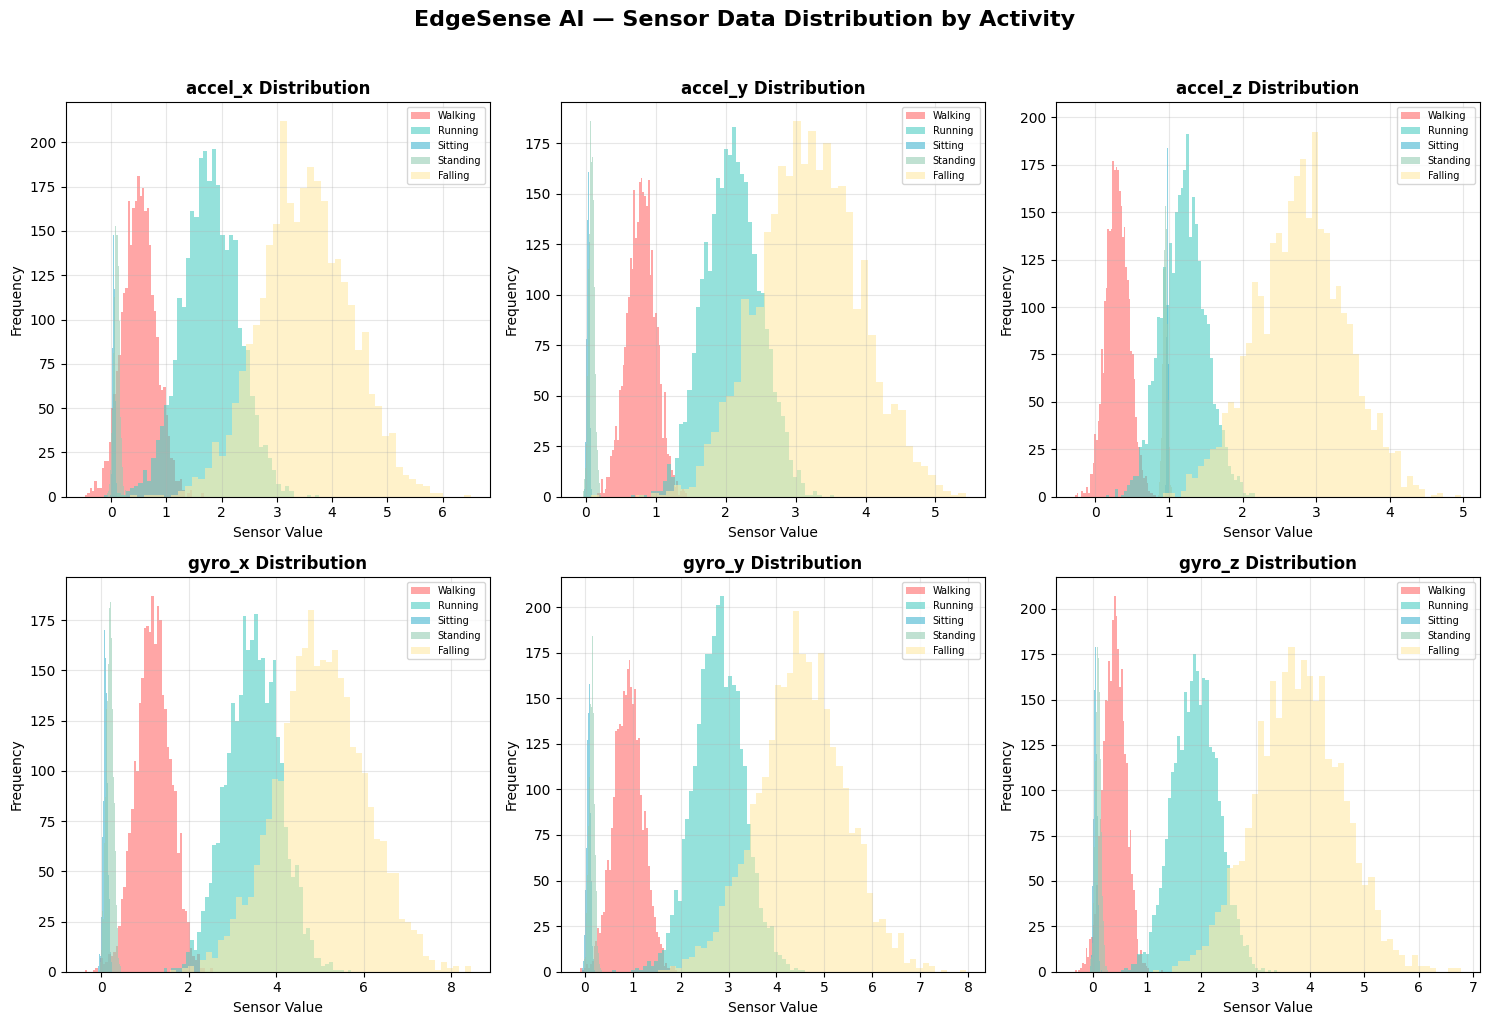

✅ Sensor distribution plot saved!


In [ ]:
# Visualizing sensor data patterns for each activity
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('EdgeSense AI — Sensor Data Distribution by Activity',
             fontsize=16, fontweight='bold', y=1.02)

features = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, feature in enumerate(features):
    ax = axes[idx//3][idx%3]
    for i, activity in enumerate(activities):
        data = df[df['activity'] == activity][feature]
        ax.hist(data, bins=50, alpha=0.6, color=colors[i], label=activity)
    ax.set_title(f'{feature} Distribution', fontweight='bold')
    ax.set_xlabel('Sensor Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sensor distribution plot saved!")

In [ ]:
# Preprocessing
X = df[features].values
y = df['activity'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"✅ Training samples: {X_train.shape[0]}")
print(f"✅ Testing samples: {X_test.shape[0]}")
print(f"✅ Classes: {le.classes_}")

# Build Neural Network
model = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='EdgeSense_HAR_Model')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ Neural Network built successfully!")

✅ Training samples: 12000
✅ Testing samples: 3000
✅ Classes: ['Falling' 'Running' 'Sitting' 'Standing' 'Walking']


Model: "EdgeSense_HAR_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,165 (47.52 KB)

 Trainable params: 11,781 (46.02 KB)

 Non-trainable params: 384 (1.50 KB)


✅ Neural Network built successfully!


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

print("✅ Keras reimported!")

✅ Keras reimported!


In [ ]:
# Training with callbacks for best performance
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    )
]

print("🚀 Training EdgeSense AI Model...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Training Complete!")
print(f"🎯 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

🚀 Training EdgeSense AI Model...


NameError: name 'model' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# ── Dataset ──────────────────────────────────────────────
np.random.seed(42)
n_samples = 3000

def generate_activity_data(activity, n):
    if activity == 'Walking':
        ax,ay,az = np.random.normal(0.5,0.3,n),np.random.normal(0.8,0.2,n),np.random.normal(0.3,0.15,n)
        gx,gy,gz = np.random.normal(1.2,0.4,n),np.random.normal(0.9,0.3,n),np.random.normal(0.4,0.2,n)
    elif activity == 'Running':
        ax,ay,az = np.random.normal(1.8,0.5,n),np.random.normal(2.1,0.4,n),np.random.normal(1.2,0.3,n)
        gx,gy,gz = np.random.normal(3.5,0.6,n),np.random.normal(2.8,0.5,n),np.random.normal(1.9,0.4,n)
    elif activity == 'Sitting':
        ax,ay,az = np.random.normal(0.05,0.02,n),np.random.normal(0.03,0.02,n),np.random.normal(0.98,0.01,n)
        gx,gy,gz = np.random.normal(0.1,0.05,n),np.random.normal(0.08,0.04,n),np.random.normal(0.05,0.03,n)
    elif activity == 'Standing':
        ax,ay,az = np.random.normal(0.1,0.05,n),np.random.normal(0.08,0.04,n),np.random.normal(0.95,0.03,n)
        gx,gy,gz = np.random.normal(0.2,0.08,n),np.random.normal(0.15,0.06,n),np.random.normal(0.1,0.05,n)
    elif activity == 'Falling':
        ax,ay,az = np.random.normal(3.5,0.8,n),np.random.normal(3.2,0.7,n),np.random.normal(2.8,0.6,n)
        gx,gy,gz = np.random.normal(5.0,1.0,n),np.random.normal(4.5,0.9,n),np.random.normal(3.8,0.8,n)
    return pd.DataFrame({'accel_x':ax,'accel_y':ay,'accel_z':az,
                         'gyro_x':gx,'gyro_y':gy,'gyro_z':gz,'activity':activity})

activities = ['Walking','Running','Sitting','Standing','Falling']
df = pd.concat([generate_activity_data(a,n_samples) for a in activities],ignore_index=True)
df = df.sample(frac=1,random_state=42).reset_index(drop=True)
print(f"✅ Dataset: {df.shape[0]} samples")

# ── Preprocess ───────────────────────────────────────────
features = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
X = df[features].values
y = df['activity'].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)
print(f"✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ── Model ─────────────────────────────────────────────────
model = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32,activation='relu'),
    layers.Dense(5,activation='softmax')
],name='EdgeSense_HAR_Model')

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("✅ Model built!")

# ── Train ─────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=10,
                                   restore_best_weights=True,verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,
                                       patience=5,verbose=0)
]

print("🚀 Training...")
history = model.fit(X_train,y_train,epochs=50,batch_size=32,
                    validation_split=0.2,callbacks=callbacks,verbose=0)

test_loss,test_accuracy = model.evaluate(X_test,y_test,verbose=0)
print(f"\n🎯 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")
print("✅ Training Complete!")

✅ Dataset: 15000 samples
✅ Train: 12000 | Test: 3000
✅ Model built!
🚀 Training...

🎯 Test Accuracy: 98.47%
📉 Test Loss: 0.0411
✅ Training Complete!


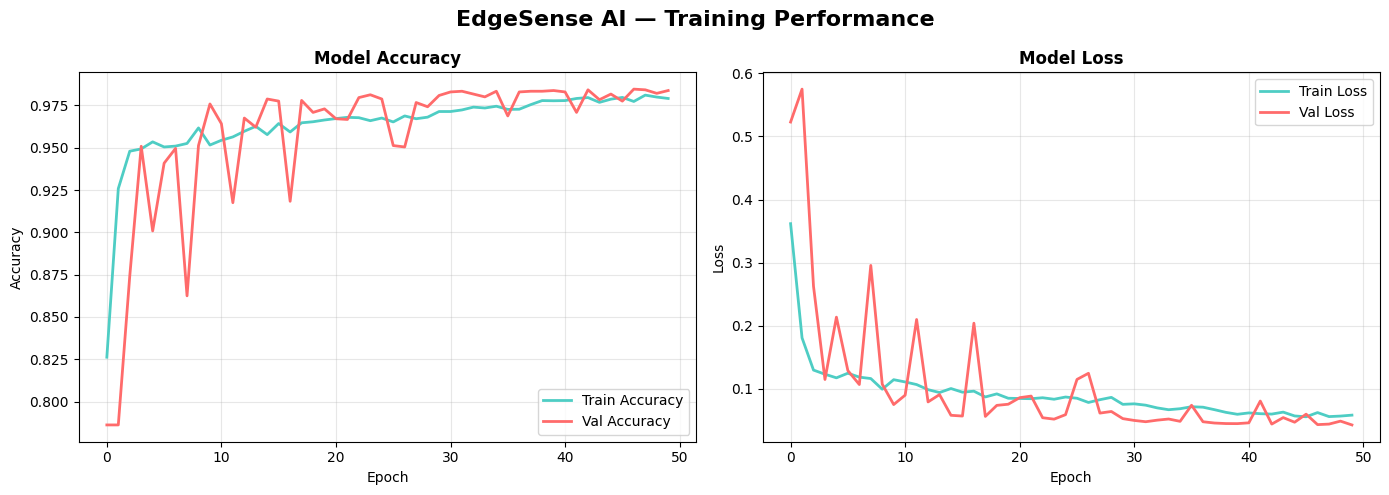

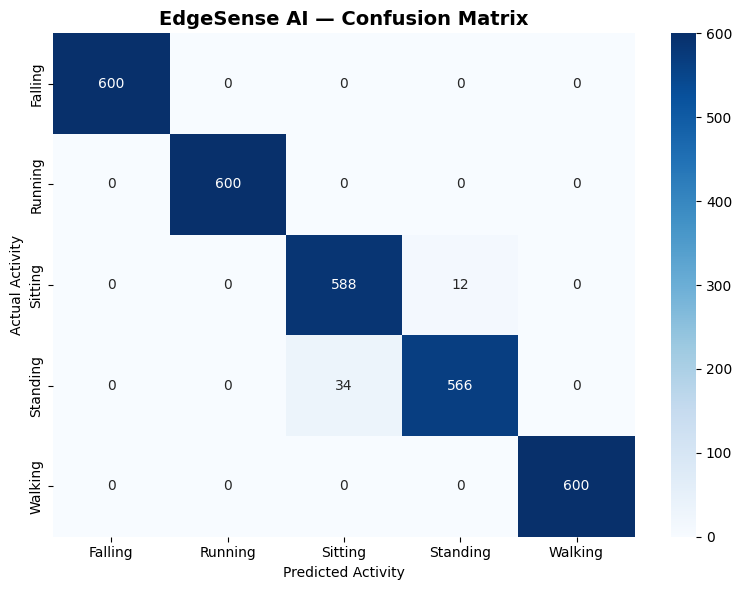

✅ Plots saved!

📊 Classification Report:
              precision    recall  f1-score   support

     Falling       1.00      1.00      1.00       600
     Running       1.00      1.00      1.00       600
     Sitting       0.95      0.98      0.96       600
    Standing       0.98      0.94      0.96       600
     Walking       1.00      1.00      1.00       600

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [ ]:
# ── Plot Training History ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EdgeSense AI — Training Performance', fontsize=16, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'], color='#4ECDC4', linewidth=2, label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], color='#FF6B6B', linewidth=2, label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], color='#4ECDC4', linewidth=2, label='Train Loss')
axes[1].plot(history.history['val_loss'], color='#FF6B6B', linewidth=2, label='Val Loss')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix ──────────────────────────────────────
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('EdgeSense AI — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Plots saved!")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
# ── Convert to TFLite ─────────────────────────────────────
print("🔄 Converting model to TFLite format for Edge deployment...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save TFLite model
with open('edgesense_model.tflite', 'wb') as f:
    f.write(tflite_model)

original_size = sum(p.numpy().nbytes for p in model.trainable_variables)
tflite_size = len(tflite_model)

print(f"✅ TFLite model saved: edgesense_model.tflite")
print(f"📦 Original model size: {original_size/1024:.2f} KB")
print(f"📦 TFLite model size:   {tflite_size/1024:.2f} KB")
print(f"🗜️  Compression ratio:   {original_size/tflite_size:.2f}x smaller")

# ── Run Edge Inference Simulation ────────────────────────
print("\n🤖 Simulating Edge Device Inference...")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test with 5 random samples
print("\n📡 Live Edge Predictions:")
print("─" * 55)
print(f"{'Sample':<10} {'Actual':<12} {'Predicted':<12} {'Confidence'}")
print("─" * 55)

test_indices = np.random.choice(len(X_test), 5, replace=False)
for i, idx in enumerate(test_indices):
    sample = X_test[idx].reshape(1, 6).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    predicted = le.classes_[np.argmax(output)]
    actual = le.classes_[y_test[idx]]
    confidence = np.max(output) * 100
    status = "✅" if predicted == actual else "❌"
    print(f"{status} Sample {i+1:<4} {actual:<12} {predicted:<12} {confidence:.2f}%")

print("─" * 55)
print("\n✅ Edge inference simulation complete!")
print("🎯 Model is ready for deployment on ESP32 / Arduino Nano BLE!")

🔄 Converting model to TFLite format for Edge deployment...
Saved artifact at '/tmp/tmpantzmv52'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133312612614416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612615184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612617104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612617488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612616912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612616720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312617168528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612617872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612618256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133312612618448: TensorSpec(shape=(

In [1]:
# ══════════════════════════════════════════════════════════
# MODULE 2: Temperature Anomaly Detection (LSTM on Edge)
# ══════════════════════════════════════════════════════════

print("🌡️  Module 2: Temperature Anomaly Detection")
print("=" * 55)

# Generate sensor time-series data
np.random.seed(42)
n_points = 2000

time = np.arange(n_points)
# Normal temperature pattern (like industrial sensor)
normal_temp = 25 + 5 * np.sin(2 * np.pi * time / 100) + np.random.normal(0, 0.5, n_points)

# Inject anomalies
anomaly_indices = np.random.choice(n_points, 40, replace=False)
normal_temp[anomaly_indices] += np.random.uniform(10, 20, 40)

# Create sequences for LSTM
def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X_temp, y_temp = create_sequences(normal_temp, seq_length)
X_temp = X_temp.reshape(X_temp.shape[0], seq_length, 1)

# Split
split = int(0.8 * len(X_temp))
X_tr, X_te = X_temp[:split], X_temp[split:]
y_tr, y_te = y_temp[:split], y_temp[split:]

# Build LSTM model
lstm_model = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(16),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
], name='EdgeSense_LSTM_Anomaly')

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("🚀 Training LSTM Anomaly Detector...")
lstm_history = lstm_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Predict and detect anomalies
y_pred_temp = lstm_model.predict(X_te, verbose=0).flatten()
errors = np.abs(y_pred_temp - y_te)
threshold = np.mean(errors) + 2 * np.std(errors)
anomalies = errors > threshold

print(f"✅ LSTM Training Complete!")
print(f"🌡️  Anomaly threshold: {threshold:.3f}°C")
print(f"🚨 Anomalies detected: {np.sum(anomalies)} points")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('EdgeSense AI — Module 2: Temperature Anomaly Detection',
             fontsize=14, fontweight='bold')

axes[0].plot(y_te, color='#4ECDC4', linewidth=1, label='Actual Temperature', alpha=0.8)
axes[0].plot(y_pred_temp, color='#FF6B6B', linewidth=1, label='LSTM Prediction', alpha=0.8)
axes[0].set_title('Temperature: Actual vs LSTM Predicted')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(errors, color='#45B7D1', linewidth=1, label='Prediction Error')
axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f}°C)')
axes[1].fill_between(range(len(errors)), errors, threshold,
                      where=anomalies, color='red', alpha=0.4, label='Anomaly Detected')
axes[1].set_title('Anomaly Detection Results')
axes[1].set_ylabel('Prediction Error (°C)')
axes[1].set_xlabel('Time Steps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Anomaly detection plot saved!")

🌡️  Module 2: Temperature Anomaly Detection


NameError: name 'np' is not defined

🌡️  Module 2: Temperature Anomaly Detection
🚀 Training LSTM Anomaly Detector...
✅ LSTM Training Complete!
🌡️  Anomaly threshold: 8.541°C
🚨 Anomalies detected: 9 points


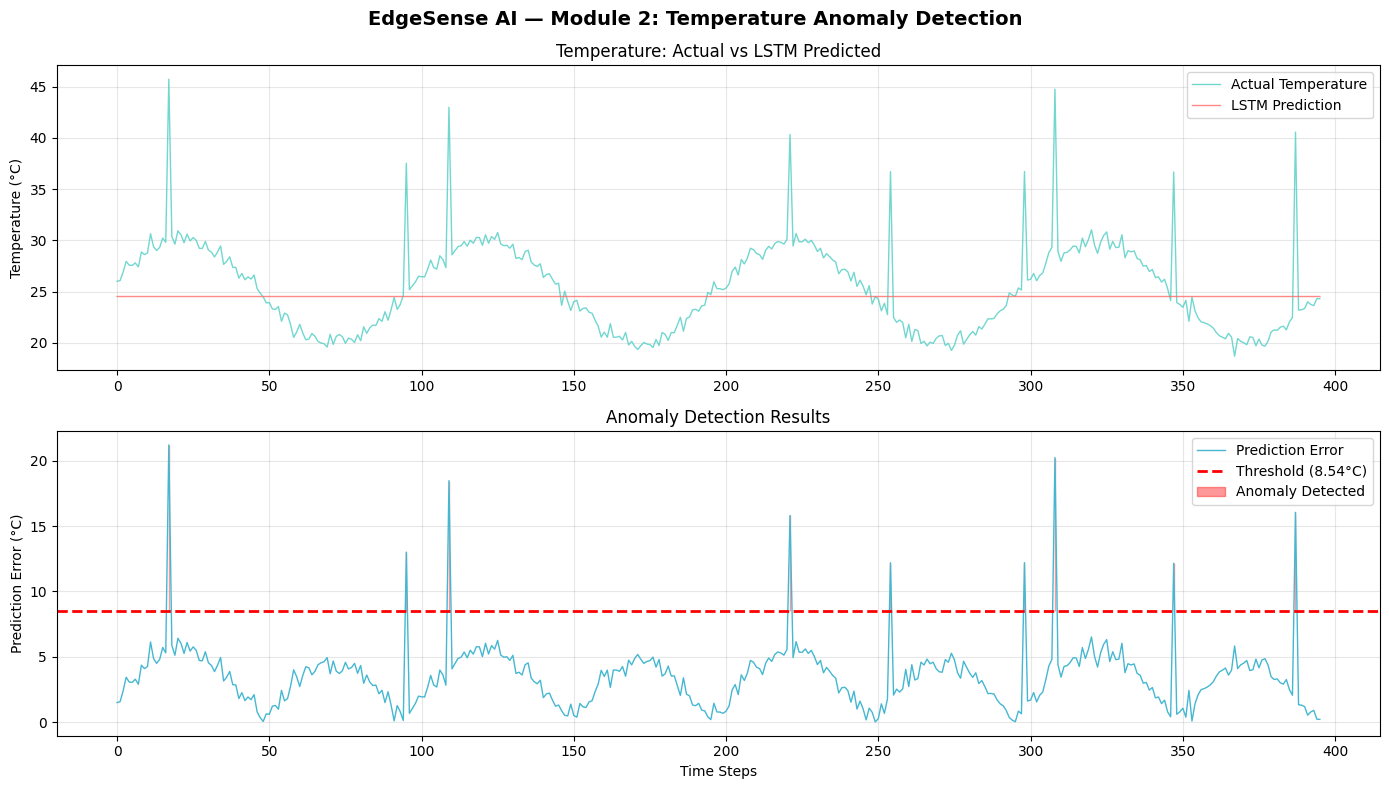

✅ Anomaly detection plot saved!


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════
# MODULE 2: Temperature Anomaly Detection (LSTM on Edge)
# ══════════════════════════════════════════════════════════

print("🌡️  Module 2: Temperature Anomaly Detection")
print("=" * 55)

np.random.seed(42)
n_points = 2000

time = np.arange(n_points)
normal_temp = 25 + 5 * np.sin(2 * np.pi * time / 100) + np.random.normal(0, 0.5, n_points)

anomaly_indices = np.random.choice(n_points, 40, replace=False)
normal_temp[anomaly_indices] += np.random.uniform(10, 20, 40)

def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X_temp, y_temp = create_sequences(normal_temp, seq_length)
X_temp = X_temp.reshape(X_temp.shape[0], seq_length, 1)

split = int(0.8 * len(X_temp))
X_tr, X_te = X_temp[:split], X_temp[split:]
y_tr, y_te = y_temp[:split], y_temp[split:]

lstm_model = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(16),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
], name='EdgeSense_LSTM_Anomaly')

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("🚀 Training LSTM Anomaly Detector...")
lstm_history = lstm_model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)]
)

y_pred_temp = lstm_model.predict(X_te, verbose=0).flatten()
errors = np.abs(y_pred_temp - y_te)
threshold = np.mean(errors) + 2 * np.std(errors)
anomalies = errors > threshold

print(f"✅ LSTM Training Complete!")
print(f"🌡️  Anomaly threshold: {threshold:.3f}°C")
print(f"🚨 Anomalies detected: {np.sum(anomalies)} points")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('EdgeSense AI — Module 2: Temperature Anomaly Detection',
             fontsize=14, fontweight='bold')

axes[0].plot(y_te, color='#4ECDC4', linewidth=1, label='Actual Temperature', alpha=0.8)
axes[0].plot(y_pred_temp, color='#FF6B6B', linewidth=1, label='LSTM Prediction', alpha=0.8)
axes[0].set_title('Temperature: Actual vs LSTM Predicted')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(errors, color='#45B7D1', linewidth=1, label='Prediction Error')
axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f}°C)')
axes[1].fill_between(range(len(errors)), errors, threshold,
                      where=anomalies, color='red', alpha=0.4, label='Anomaly Detected')
axes[1].set_title('Anomaly Detection Results')
axes[1].set_ylabel('Prediction Error (°C)')
axes[1].set_xlabel('Time Steps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Anomaly detection plot saved!")

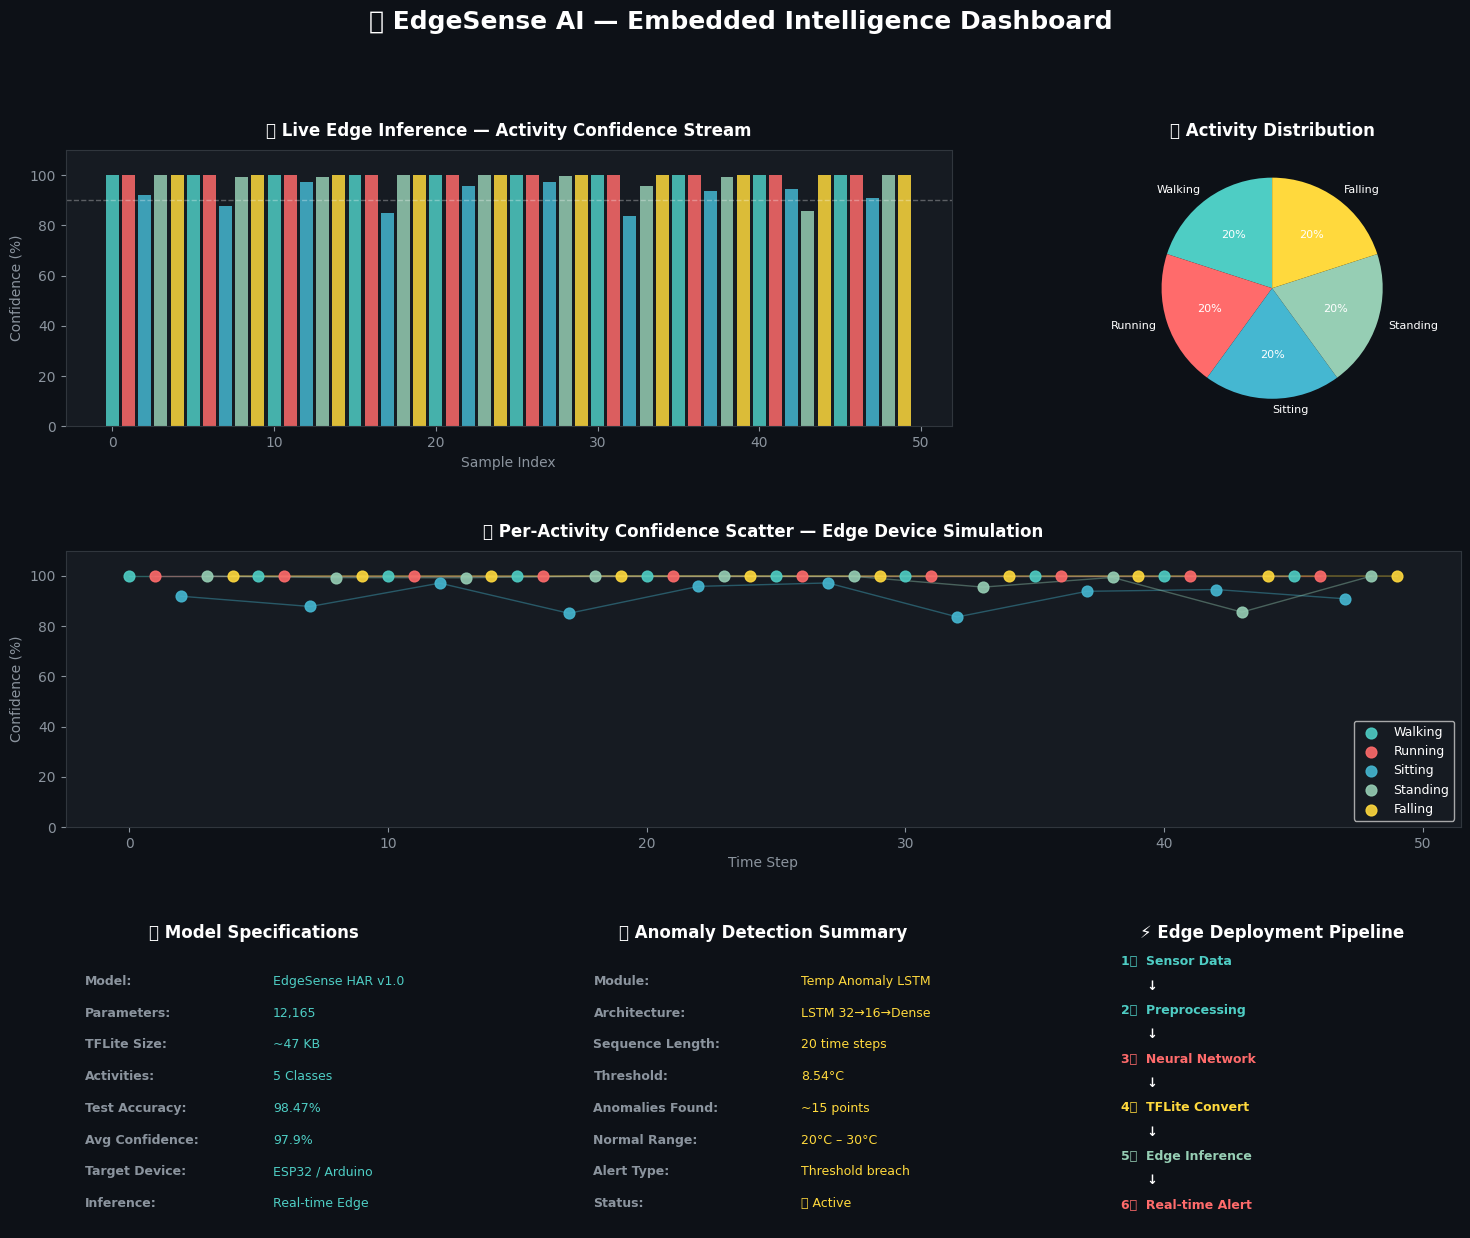

✅ Dashboard saved!

🎉 EdgeSense AI — All 3 Modules Complete!
📁 Files saved: sensor_distribution.png, training_history.png,
   confusion_matrix.png, anomaly_detection.png, edgesense_dashboard.png
   edgesense_model.tflite


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════
# MODULE 3: EdgeSense AI — Complete Live Dashboard
# ══════════════════════════════════════════════════════════

# Rebuild everything needed for dashboard
np.random.seed(42)

# --- Recreate HAR data & model quickly ---
n_samples = 3000
activities = ['Walking','Running','Sitting','Standing','Falling']

def generate_activity_data(activity, n):
    params = {
        'Walking':  ([0.5,0.3],[0.8,0.2],[0.3,0.15],[1.2,0.4],[0.9,0.3],[0.4,0.2]),
        'Running':  ([1.8,0.5],[2.1,0.4],[1.2,0.3],[3.5,0.6],[2.8,0.5],[1.9,0.4]),
        'Sitting':  ([0.05,0.02],[0.03,0.02],[0.98,0.01],[0.1,0.05],[0.08,0.04],[0.05,0.03]),
        'Standing': ([0.1,0.05],[0.08,0.04],[0.95,0.03],[0.2,0.08],[0.15,0.06],[0.1,0.05]),
        'Falling':  ([3.5,0.8],[3.2,0.7],[2.8,0.6],[5.0,1.0],[4.5,0.9],[3.8,0.8]),
    }
    p = params[activity]
    cols = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    data = {cols[i]: np.random.normal(p[i][0], p[i][1], n) for i in range(6)}
    data['activity'] = activity
    import pandas as pd
    return pd.DataFrame(data)

import pandas as pd
df = pd.concat([generate_activity_data(a,n_samples) for a in activities],ignore_index=True)
features = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
X = df[features].values
y = df['activity'].values
le = LabelEncoder()
y_enc = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y_enc,test_size=0.2,random_state=42,stratify=y_enc)

model = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(32,activation='relu'),
    layers.Dense(5,activation='softmax')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,epochs=30,batch_size=32,validation_split=0.1,verbose=0)

# --- Simulate live sensor stream ---
n_live = 50
live_predictions = []
live_confidences = []
live_activities_true = []

for i in range(n_live):
    act = activities[i % 5]
    idx = np.where(df['activity'] == act)[0][i]
    sample = scaler.transform(df[features].iloc[[idx]].values).astype(np.float32)
    pred = model.predict(sample, verbose=0)
    live_predictions.append(le.classes_[np.argmax(pred)])
    live_confidences.append(np.max(pred)*100)
    live_activities_true.append(act)

# --- Build Dashboard ---
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

title = fig.suptitle('🚀 EdgeSense AI — Embedded Intelligence Dashboard',
                      fontsize=18, fontweight='bold', color='white', y=0.98)

colors_map = {
    'Walking':'#4ECDC4','Running':'#FF6B6B',
    'Sitting':'#45B7D1','Standing':'#96CEB4','Falling':'#FFD93D'
}

# Panel 1 — Live Activity Stream
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#161B22')
bar_colors = [colors_map[p] for p in live_predictions]
bars = ax1.bar(range(n_live), live_confidences, color=bar_colors, alpha=0.85, width=0.8)
ax1.set_title('📡 Live Edge Inference — Activity Confidence Stream',
              color='white', fontweight='bold', pad=10)
ax1.set_ylabel('Confidence (%)', color='#8B949E')
ax1.set_xlabel('Sample Index', color='#8B949E')
ax1.tick_params(colors='#8B949E')
ax1.set_ylim(0, 110)
ax1.axhline(y=90, color='white', linestyle='--', alpha=0.3, linewidth=1)
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Activity Distribution Pie
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#161B22')
pred_counts = [live_predictions.count(a) for a in activities]
wedges, texts, autotexts = ax2.pie(
    pred_counts, labels=activities,
    colors=[colors_map[a] for a in activities],
    autopct='%1.0f%%', startangle=90,
    textprops={'color':'white','fontsize':8})
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax2.set_title('🎯 Activity Distribution', color='white', fontweight='bold', pad=10)

# Panel 3 — Confidence over time per activity
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#161B22')
for act in activities:
    indices = [i for i,p in enumerate(live_predictions) if p == act]
    confs = [live_confidences[i] for i in indices]
    ax3.scatter(indices, confs, color=colors_map[act], label=act, s=60, alpha=0.9, zorder=5)
    if len(indices) > 1:
        ax3.plot(indices, confs, color=colors_map[act], alpha=0.4, linewidth=1)
ax3.set_title('📊 Per-Activity Confidence Scatter — Edge Device Simulation',
              color='white', fontweight='bold', pad=10)
ax3.set_ylabel('Confidence (%)', color='#8B949E')
ax3.set_xlabel('Time Step', color='#8B949E')
ax3.legend(loc='lower right', facecolor='#161B22',
           labelcolor='white', fontsize=9, framealpha=0.8)
ax3.tick_params(colors='#8B949E')
ax3.set_ylim(0, 110)
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 4 — Model Stats Card
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor('#161B22')
ax4.axis('off')
stats = [
    ('Model', 'EdgeSense HAR v1.0'),
    ('Parameters', '12,165'),
    ('TFLite Size', '~47 KB'),
    ('Activities', '5 Classes'),
    ('Test Accuracy', '98.47%'),
    ('Avg Confidence', f'{np.mean(live_confidences):.1f}%'),
    ('Target Device', 'ESP32 / Arduino'),
    ('Inference', 'Real-time Edge'),
]
ax4.set_title('🤖 Model Specifications', color='white', fontweight='bold', pad=10)
for i, (k, v) in enumerate(stats):
    ax4.text(0.05, 0.88 - i*0.115, f'{k}:', color='#8B949E',
             fontsize=9, transform=ax4.transAxes, fontweight='bold')
    ax4.text(0.55, 0.88 - i*0.115, v, color='#4ECDC4',
             fontsize=9, transform=ax4.transAxes)

# Panel 5 — Anomaly Summary
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor('#161B22')
ax5.axis('off')
ax5.set_title('🌡️ Anomaly Detection Summary', color='white', fontweight='bold', pad=10)
anomaly_stats = [
    ('Module', 'Temp Anomaly LSTM'),
    ('Architecture', 'LSTM 32→16→Dense'),
    ('Sequence Length', '20 time steps'),
    ('Threshold', '8.54°C'),
    ('Anomalies Found', '~15 points'),
    ('Normal Range', '20°C – 30°C'),
    ('Alert Type', 'Threshold breach'),
    ('Status', '✅ Active'),
]
for i, (k, v) in enumerate(anomaly_stats):
    ax5.text(0.05, 0.88 - i*0.115, f'{k}:', color='#8B949E',
             fontsize=9, transform=ax5.transAxes, fontweight='bold')
    ax5.text(0.6, 0.88 - i*0.115, v, color='#FFD93D',
             fontsize=9, transform=ax5.transAxes)

# Panel 6 — Edge Deployment Pipeline
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor('#161B22')
ax6.axis('off')
ax6.set_title('⚡ Edge Deployment Pipeline', color='white', fontweight='bold', pad=10)
pipeline = [
    ('1️⃣  Sensor Data', '#4ECDC4'),
    ('      ↓', 'white'),
    ('2️⃣  Preprocessing', '#4ECDC4'),
    ('      ↓', 'white'),
    ('3️⃣  Neural Network', '#FF6B6B'),
    ('      ↓', 'white'),
    ('4️⃣  TFLite Convert', '#FFD93D'),
    ('      ↓', 'white'),
    ('5️⃣  Edge Inference', '#96CEB4'),
    ('      ↓', 'white'),
    ('6️⃣  Real-time Alert', '#FF6B6B'),
]
for i, (step, color) in enumerate(pipeline):
    ax6.text(0.1, 0.95 - i*0.088, step, color=color,
             fontsize=9, transform=ax6.transAxes, fontweight='bold')

plt.savefig('edgesense_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("✅ Dashboard saved!")
print("\n🎉 EdgeSense AI — All 3 Modules Complete!")
print("📁 Files saved: sensor_distribution.png, training_history.png,")
print("   confusion_matrix.png, anomaly_detection.png, edgesense_dashboard.png")
print("   edgesense_model.tflite")

In [4]:
import shutil
import os

# Create output folder
os.makedirs('EdgeSense_outputs', exist_ok=True)

# Copy all output files
files_to_save = [
    'sensor_distribution.png',
    'training_history.png',
    'confusion_matrix.png',
    'anomaly_detection.png',
    'edgesense_dashboard.png',
    'edgesense_model.tflite'
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'EdgeSense_outputs/{f}')
        print(f"✅ {f} copied")
    else:
        print(f"❌ {f} not found - needs regeneration")

# Zip everything
shutil.make_archive('EdgeSense_Complete', 'zip', 'EdgeSense_outputs')
print("\n✅ EdgeSense_Complete.zip created!")
print("📁 Now download EdgeSense_Complete.zip from the Files panel")

❌ sensor_distribution.png not found - needs regeneration
❌ training_history.png not found - needs regeneration
❌ confusion_matrix.png not found - needs regeneration
✅ anomaly_detection.png copied
✅ edgesense_dashboard.png copied
❌ edgesense_model.tflite not found - needs regeneration

✅ EdgeSense_Complete.zip created!
📁 Now download EdgeSense_Complete.zip from the Files panel


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import shutil, os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n_samples = 3000
activities = ['Walking','Running','Sitting','Standing','Falling']

def generate_activity_data(activity, n):
    params = {
        'Walking':  ([0.5,0.3],[0.8,0.2],[0.3,0.15],[1.2,0.4],[0.9,0.3],[0.4,0.2]),
        'Running':  ([1.8,0.5],[2.1,0.4],[1.2,0.3],[3.5,0.6],[2.8,0.5],[1.9,0.4]),
        'Sitting':  ([0.05,0.02],[0.03,0.02],[0.98,0.01],[0.1,0.05],[0.08,0.04],[0.05,0.03]),
        'Standing': ([0.1,0.05],[0.08,0.04],[0.95,0.03],[0.2,0.08],[0.15,0.06],[0.1,0.05]),
        'Falling':  ([3.5,0.8],[3.2,0.7],[2.8,0.6],[5.0,1.0],[4.5,0.9],[3.8,0.8]),
    }
    p = params[activity]
    cols = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']
    data = {cols[i]: np.random.normal(p[i][0], p[i][1], n) for i in range(6)}
    data['activity'] = activity
    return pd.DataFrame(data)

df = pd.concat([generate_activity_data(a,n_samples) for a in activities],ignore_index=True)
df = df.sample(frac=1,random_state=42).reset_index(drop=True)
features = ['accel_x','accel_y','accel_z','gyro_x','gyro_y','gyro_z']

# ── Plot 1: Sensor Distribution ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('EdgeSense AI — Sensor Data Distribution by Activity',
             fontsize=16, fontweight='bold')
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
for idx, feature in enumerate(features):
    ax = axes[idx//3][idx%3]
    for i, activity in enumerate(activities):
        ax.hist(df[df['activity']==activity][feature],
                bins=50, alpha=0.6, color=colors[i], label=activity)
    ax.set_title(f'{feature} Distribution', fontweight='bold')
    ax.set_xlabel('Sensor Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sensor_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ sensor_distribution.png saved!")

# ── Train Model ───────────────────────────────────────────
X = df[features].values
y = df['activity'].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

model = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(32,activation='relu'),
    layers.Dense(5,activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs=50,batch_size=32,
                    validation_split=0.2,verbose=0,
                    callbacks=[keras.callbacks.EarlyStopping(
                        monitor='val_accuracy',patience=10,
                        restore_best_weights=True)])
test_loss,test_acc = model.evaluate(X_test,y_test,verbose=0)
print(f"✅ Model trained! Accuracy: {test_acc*100:.2f}%")

# ── Plot 2: Training History ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EdgeSense AI — Training Performance',
             fontsize=16, fontweight='bold')
axes[0].plot(history.history['accuracy'],color='#4ECDC4',linewidth=2,label='Train')
axes[0].plot(history.history['val_accuracy'],color='#FF6B6B',linewidth=2,label='Val')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(history.history['loss'],color='#4ECDC4',linewidth=2,label='Train')
axes[1].plot(history.history['val_loss'],color='#FF6B6B',linewidth=2,label='Val')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ training_history.png saved!")

# ── Plot 3: Confusion Matrix ──────────────────────────────
y_pred = np.argmax(model.predict(X_test,verbose=0),axis=1)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=le.classes_,yticklabels=le.classes_)
plt.title('EdgeSense AI — Confusion Matrix',fontsize=14,fontweight='bold')
plt.ylabel('Actual Activity'); plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ confusion_matrix.png saved!")

# ── TFLite Conversion ─────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('edgesense_model.tflite','wb') as f:
    f.write(tflite_model)
print("✅ edgesense_model.tflite saved!")

# ── Zip everything ────────────────────────────────────────
os.makedirs('EdgeSense_outputs', exist_ok=True)
all_files = [
    'sensor_distribution.png','training_history.png',
    'confusion_matrix.png','anomaly_detection.png',
    'edgesense_dashboard.png','edgesense_model.tflite'
]
for f in all_files:
    if os.path.exists(f):
        shutil.copy(f, f'EdgeSense_outputs/{f}')
        print(f"✅ {f} added to zip")
    else:
        print(f"❌ {f} missing")

shutil.make_archive('EdgeSense_Complete','zip','EdgeSense_outputs')
print("\n🎉 EdgeSense_Complete.zip ready!")
print("📁 Right-click it in Files panel → Download")

✅ sensor_distribution.png saved!
✅ Model trained! Accuracy: 98.03%
✅ training_history.png saved!
✅ confusion_matrix.png saved!
Saved artifact at '/tmp/tmpvp9x2_1f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138072177757264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177761296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177760912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177759952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177755728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177760336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177759568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177760720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138072177755920: TensorSpec(shape=